# Small-Cap Quality Factor Portfolio — v2 Pipeline

Does screening small-cap U.S. stocks on accounting-based quality improve on a naive small-cap index (IWM)? This notebook runs the full pipeline from raw data to final results in one pass.

It starts from the original course notebook (see `original/`) and fixes the issues documented in `AUDIT.md`, one at a time. Each fix is marked in the code with a `v2 FIX #` comment.

**Pipeline**
1. Setup
2. Small-cap universe (CRSP)
3. Quality measures (Compustat)
4. Merge and composite quality score
5. Quintile sort
6. Long-short regression
7. Top-200 portfolio and IWM benchmark
8. Long-only regression
9. Portfolio statistics
10. Cumulative returns
11. Stress periods
12. Risks and limitations

**Required input files** (licensed WRDS data is not included in this repo; place files in `DATA_DIR`):
- `crsp_raw.csv` — CRSP monthly stock file (CIZ format) from WRDS
- `quality_measures.csv` — Compustat quality measures, annual, aligned to June
- `cusip_link.csv` — CRSP–Compustat linking table
- `ff3_factors.csv` — Fama-French 3-factor returns (Ken French Data Library)
- `IWM_rets.csv` — IWM monthly returns from CRSP (PERMNO 88222)

## Change log

| Fix | Audit issue | Change |
|---|---|---|
| #1 | Newey-West SEs inflated by a factor of n | Removed the factor of n in `newey_west_se`; added an OLS sanity check |


## 1. Setup

Imports, data folder and portfolio settings.

In [1]:
import os, warnings
import pandas as pd
import numpy as np
from scipy import stats
from numpy.linalg import lstsq
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

# CONFIG
DATA_DIR = os.path.expanduser('~/Downloads')  
def p(f): return os.path.join(DATA_DIR, f)

TOP_N = 200                    # top 200 quality stocks
REBAL_MONTHS = [3, 6, 9, 12]  # quarterly rebalancing

## 2. Small-cap universe (CRSP)

U.S. common stocks between the 20th and 50th NYSE market-equity percentiles with a minimum price of $5.

In [2]:
print("=" * 60)
print("STEP 2 — SMALL-CAP UNIVERSE")
print("=" * 60)

raw = pd.read_csv(p('crsp_raw.csv'))
print(f"Raw CRSP: {raw.shape[0]:,} rows, {raw['PERMNO'].nunique():,} stocks")

# Rename CIZ columns to match pipeline
raw = raw.rename(columns={
    'MthCalDt':    'date',
    'MthPrevPrc':  'PRC',
    'MthPrevCap':  'me',
    'MthRet':      'RET',
    'HdrCUSIP':    'CUSIP',
    'PrimaryExch': 'PRIMEXCH'
})

# Filter to common stocks only (EQTY + COM = share codes 10/11 equivalent)
raw = raw[(raw['SecurityType'] == 'EQTY') & (raw['SecuritySubType'] == 'COM')].copy()

raw['PRC']  = pd.to_numeric(raw['PRC'],  errors='coerce').abs()
raw['RET']  = pd.to_numeric(raw['RET'],  errors='coerce')
raw['me']   = pd.to_numeric(raw['me'],   errors='coerce')
raw['date'] = pd.to_datetime(raw['date'], errors='coerce')

raw = raw.dropna(subset=['PRC', 'RET', 'me', 'date']).copy()
raw = raw[raw['PRC'] >= 5].copy()
raw['year_month'] = raw['date'].dt.to_period('M').astype(str)
print(f"After price >= $5: {raw.shape[0]:,} rows")

# NYSE breakpoints (NYSE = 'N' in CIZ)
nyse = raw[raw['PRIMEXCH'] == 'N']
bp = nyse.groupby('year_month')['me'].quantile([0.20, 0.50]).unstack()
bp.columns = ['p20', 'p50']
bp = bp.reset_index()

raw = raw.merge(bp, on='year_month', how='left')
crsp = raw[(raw['me'] >= raw['p20']) & (raw['me'] <= raw['p50'])].copy()

crsp = crsp.rename(columns={'PRC':'prc','RET':'ret','CUSIP':'HdrCUSIP','PRIMEXCH':'PrimaryExch'})
crsp['cusip8'] = crsp['HdrCUSIP'].astype(str).str[:8]

print(f"\nSmall-cap universe: {crsp.shape[0]:,} stock-months, {crsp['PERMNO'].nunique():,} stocks")
print(f"Date range: {crsp['year_month'].min()} to {crsp['year_month'].max()}")

STEP 2 — SMALL-CAP UNIVERSE
Raw CRSP: 2,423,212 rows, 25,301 stocks
After price >= $5: 1,317,552 rows

Small-cap universe: 363,612 stock-months, 8,161 stocks
Date range: 2000-01 to 2025-12


## 3. Quality measures (Compustat)

Five measures, each z-scored cross-sectionally:
- **Safety:** earnings volatility (lower is better)
- **Payout:** net payout yield (higher is better)
- **Investment:** CAPX / total assets (lower is better)
- **Profitability:** return on assets
- **Growth:** five-year change in net income scaled by assets

Annual data is aligned to June and used from July through the following June.

In [3]:
print("=" * 60)
print("STEP 3 — QUALITY MEASURES")
print("=" * 60)

quality = pd.read_csv(p('quality_measures.csv'))
quality['merge_date'] = pd.to_datetime(quality['merge_date'], errors='coerce')
quality['quality_year'] = quality['merge_date'].dt.year
print(f"Quality measures: {quality.shape[0]:,} rows (annual, June)")

cusip_link = pd.read_csv(p('cusip_link.csv'))
cusip_link['cusip8'] = cusip_link['cusip'].astype(str).str[:8]
print(f"CUSIP link: {cusip_link.shape[0]:,} rows")

STEP 3 — QUALITY MEASURES
Quality measures: 254,253 rows (annual, June)
CUSIP link: 32,798 rows


## 4. Merge and composite quality score

Link quality measures to CRSP returns, build the composite score, and load the Fama-French factors.

In [4]:
print("=" * 60)
print("STEP 4 — MERGE & QUALITY SCORE")
print("=" * 60)

# Quality vintage: month >= July -> same year; month <= June -> previous year
crsp['quality_year'] = np.where(
    crsp['date'].dt.month >= 7,
    crsp['date'].dt.year,
    crsp['date'].dt.year - 1
)

# Include roa_growth if available in quality measures file
quality_cols = [c for c in ['earnings_volatility','net_payout','investment_rate','roa','roa_growth']
                if c in quality.columns]
print(f"Quality measures available: {quality_cols}")

merged = crsp.merge(cusip_link[['cusip8','gvkey']].drop_duplicates(), on='cusip8', how='left')
merged = merged.merge(
    quality[['gvkey','quality_year'] + quality_cols],
    on=['gvkey','quality_year'], how='left'
)

for col in quality_cols + ['ret']:
    merged[col] = pd.to_numeric(merged[col], errors='coerce')
merged = merged.dropna(subset=quality_cols + ['ret']).copy()

print(f"Merged: {merged.shape[0]:,} stock-months, {merged['PERMNO'].nunique():,} stocks, {merged['year_month'].nunique()} months")

# Cross-sectional z-scores
def cs_z(s):
    return (s - s.mean()) / s.std(ddof=0) if s.std() > 0 else s * 0

# Safety: lower volatility = better -> multiply by -1 after z-scoring
# Investment: lower capex = better -> multiply by -1 after z-scoring
merged['z_ev']  = merged.groupby('year_month')['earnings_volatility'].transform(cs_z) * -1
merged['z_np']  = merged.groupby('year_month')['net_payout'].transform(cs_z)
merged['z_inv'] = merged.groupby('year_month')['investment_rate'].transform(cs_z) * -1
merged['z_roa'] = merged.groupby('year_month')['roa'].transform(cs_z)

z_cols = ['z_ev', 'z_np', 'z_inv', 'z_roa']

if 'roa_growth' in quality_cols:
    merged['z_roa_growth'] = merged.groupby('year_month')['roa_growth'].transform(cs_z)
    z_cols.append('z_roa_growth')

merged['quality_score'] = merged[z_cols].mean(axis=1)
print(f"Quality score computed from {len(z_cols)} measures: {z_cols}")


STEP 4 — MERGE & QUALITY SCORE
Quality measures available: ['earnings_volatility', 'net_payout', 'investment_rate', 'roa', 'roa_growth']
Merged: 252,229 stock-months, 4,619 stocks, 306 months
Quality score computed from 5 measures: ['z_ev', 'z_np', 'z_inv', 'z_roa', 'z_roa_growth']


In [5]:
# Load FF3 factors
ff3_raw = pd.read_csv(p('ff3_factors.csv'))
ff3_raw.columns = [c.strip() for c in ff3_raw.columns]

# Handle different possible column names
col_map = {}
for c in ff3_raw.columns:
    cl = c.lower().replace('-', '_').replace(' ', '_')
    if 'date' in cl:        col_map[c] = 'date'
    elif 'mkt' in cl:       col_map[c] = 'Mkt_RF'
    elif 'smb' in cl:       col_map[c] = 'SMB'
    elif 'hml' in cl:       col_map[c] = 'HML'
    elif cl == 'rf':        col_map[c] = 'RF'
ff3_raw = ff3_raw.rename(columns=col_map)

ff3_raw = ff3_raw[ff3_raw['date'].astype(str).str.match(r'^\d{6}$')].copy()
for col in ['Mkt_RF', 'SMB', 'HML', 'RF']:
    ff3_raw[col] = pd.to_numeric(ff3_raw[col], errors='coerce')

ff3_raw['year_month'] = ff3_raw['date'].astype(str).str[:4] + '-' + ff3_raw['date'].astype(str).str[4:6]
ff3 = ff3_raw[['year_month', 'Mkt_RF', 'SMB', 'HML', 'RF']].dropna().copy()
print(f"FF3 factors: {len(ff3)} months  |  range: {ff3['year_month'].min()} to {ff3['year_month'].max()}")
print(f"Factor means (should be small decimals): Mkt_RF={ff3['Mkt_RF'].mean():.4f}, SMB={ff3['SMB'].mean():.4f}")


FF3 factors: 314 months  |  range: 2000-01 to 2026-02
Factor means (should be small decimals): Mkt_RF=0.0061, SMB=0.0011


## 5. Quintile sort

Does the quality score predict returns within the small-cap universe?

QUINTILE SORT — Average Monthly Returns
--------------------------------------------------
  Q1 (Junk)         0.79%/mo  |     9.4% ann.
  Q2                1.04%/mo  |    12.5% ann.
  Q3                1.12%/mo  |    13.5% ann.
  Q4                1.09%/mo  |    13.1% ann.
  Q5 (Quality)      1.08%/mo  |    13.0% ann.

  Q5-Q1 spread: 0.29%/mo  |  3.5% annualized


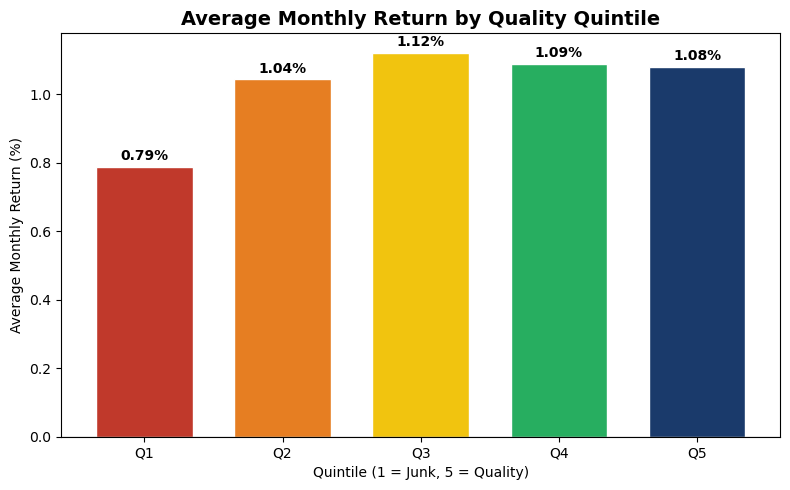

In [6]:
merged['quintile'] = merged.groupby('year_month')['quality_score'].transform(
    lambda x: pd.qcut(x, 5, labels=[1,2,3,4,5], duplicates='drop')
)
merged['quintile'] = pd.to_numeric(merged['quintile'], errors='coerce')

quintile_returns = (
    merged.groupby(['year_month','quintile'])['ret']
    .mean().reset_index().rename(columns={'ret':'ew_ret'})
)
avg_by_q = quintile_returns.groupby('quintile')['ew_ret'].mean()

print("QUINTILE SORT — Average Monthly Returns")
print("-" * 50)
for q in [1,2,3,4,5]:
    label = "(Junk)" if q == 1 else "(Quality)" if q == 5 else ""
    print(f"  Q{q} {label:<12} {avg_by_q.get(q,0)*100:>6.2f}%/mo  |  {avg_by_q.get(q,0)*1200:>6.1f}% ann.")
spread = avg_by_q.get(5,0) - avg_by_q.get(1,0)
print(f"\n  Q5-Q1 spread: {spread*100:.2f}%/mo  |  {spread*1200:.1f}% annualized")

fig, ax = plt.subplots(figsize=(8,5))
colors = ['#c0392b','#e67e22','#f1c40f','#27ae60','#1a3a6b']
(avg_by_q * 100).plot(kind='bar', ax=ax, color=colors, edgecolor='white', width=0.7)
ax.set_title('Average Monthly Return by Quality Quintile', fontsize=14, fontweight='bold')
ax.set_xlabel('Quintile (1 = Junk, 5 = Quality)')
ax.set_ylabel('Average Monthly Return (%)')
ax.set_xticklabels([f'Q{int(q)}' for q in avg_by_q.index], rotation=0)
for i, (q, v) in enumerate((avg_by_q*100).items()):
    ax.text(i, v + 0.02, f'{v:.2f}%', ha='center', fontsize=10, fontweight='bold')
ax.axhline(0, color='black', lw=0.8)
plt.tight_layout()
plt.show()

## 6. Long-short regression

Long the top quality quintile, short the bottom, regressed on the Fama-French three-factor model.

In [7]:
q5 = quintile_returns[quintile_returns['quintile']==5].set_index('year_month')['ew_ret']
q1 = quintile_returns[quintile_returns['quintile']==1].set_index('year_month')['ew_ret']
ls = (q5 - q1).dropna().reset_index()
ls.columns = ['year_month','ls_ret']

ls_ff3 = ls.merge(ff3[['year_month','Mkt_RF','SMB','HML','RF']], on='year_month', how='inner')
ls_ff3['excess_ret'] = ls_ff3['ls_ret'] - ls_ff3['RF']

y_ls = ls_ff3['excess_ret'].values
X_ls = np.column_stack([
    np.ones(len(ls_ff3)),
    ls_ff3['Mkt_RF'].values,
    ls_ff3['SMB'].values,
    ls_ff3['HML'].values
])

betas_ls, _, _, _ = lstsq(X_ls, y_ls, rcond=None)
resid_ls = y_ls - X_ls @ betas_ls
n_ls = len(y_ls)
k_ls = X_ls.shape[1]
s2_ls = resid_ls @ resid_ls / (n_ls - k_ls)
se_ls = np.sqrt(np.diag(s2_ls * np.linalg.inv(X_ls.T @ X_ls)))
t_ls = betas_ls / se_ls
r2_ls = 1 - np.var(resid_ls, ddof=0) / np.var(y_ls, ddof=0)

print("LONG-SHORT FF3 REGRESSION (Q5 - Q1)")
print("=" * 55)
for lbl, b, t in zip(['Alpha','Mkt-RF','SMB','HML'], betas_ls, t_ls):
    sig = ' ***' if abs(t) > 2.576 else ' **' if abs(t) > 1.96 else ''
    if lbl == 'Alpha':
        print(f"  {lbl:<10} {b*100:>8.3f}%/mo   t = {t:.3f}{sig}")
    else:
        print(f"  {lbl:<10} {b:>8.3f}        t = {t:.3f}{sig}")
print(f"\n  R2 = {r2_ls:.3f}  |  N = {n_ls}")
print(f"  L/S mean monthly: {ls['ls_ret'].mean()*100:.3f}%")
print(f"  L/S annualized:   {ls['ls_ret'].mean()*1200:.2f}%")

LONG-SHORT FF3 REGRESSION (Q5 - Q1)
  Alpha         0.090%/mo   t = 0.512
  Mkt-RF        0.063        t = 1.543
  SMB          -0.088        t = -1.265
  HML           0.103        t = 1.968 **

  R2 = 0.022  |  N = 306
  L/S mean monthly: 0.293%
  L/S annualized:   3.51%


## 7. Top-200 portfolio and IWM benchmark

Load IWM, build the equal-weighted top-200 quality portfolio with quarterly rebalancing, and measure turnover.

In [8]:
print("=" * 60)
print("STEP 7 — LOAD IWM BENCHMARK")
print("=" * 60)

iwm_raw = pd.read_csv(p('IWM_rets.csv'))
print(f"IWM raw columns: {list(iwm_raw.columns)}")

# Standardise column names to lowercase
iwm_raw.columns = [c.strip().lower() for c in iwm_raw.columns]

# Handle MthCalDt / date column
date_col = next((c for c in iwm_raw.columns if 'date' in c or 'dt' in c or 'cal' in c), None)
ret_col  = next((c for c in iwm_raw.columns if 'ret' in c), None)

iwm_raw = iwm_raw.rename(columns={date_col: 'date', ret_col: 'iwm_ret'})
iwm_raw['date']    = pd.to_datetime(iwm_raw['date'], errors='coerce')
iwm_raw['iwm_ret'] = pd.to_numeric(iwm_raw['iwm_ret'], errors='coerce')
iwm_raw['year_month'] = iwm_raw['date'].dt.to_period('M').astype(str)
iwm = iwm_raw[['year_month','iwm_ret']].dropna()
print(f"IWM: {iwm.shape[0]} months  |  {iwm['year_month'].min()} to {iwm['year_month'].max()}")


STEP 7 — LOAD IWM BENCHMARK
IWM raw columns: ['MthCalDt', 'IWM_Ret']
IWM: 314 months  |  2000-05 to 2025-12


In [9]:
# Build top-200 quality portfolio (quarterly rebalance)
all_months = sorted(merged['year_month'].unique())
rebal_dates = [ym for ym in all_months if int(ym.split('-')[1]) in REBAL_MONTHS]

holdings = {}
current_top200 = set()
for ym in all_months:
    if ym in rebal_dates:
        md = merged[merged['year_month'] == ym]
        top200 = md.nlargest(TOP_N, 'quality_score')['PERMNO'].unique()
        current_top200 = set(top200)
    holdings[ym] = current_top200

port_returns = []
for ym in all_months:
    if not holdings[ym]: continue
    md = merged[(merged['year_month'] == ym) & (merged['PERMNO'].isin(holdings[ym]))]
    if len(md) > 0:
        port_returns.append({'year_month': ym, 'port_ret': md['ret'].mean(), 'n_stocks': len(md)})

port_df = pd.DataFrame(port_returns)
print(f"Portfolio: {len(port_df)} months, avg {port_df['n_stocks'].mean():.0f} stocks/month")

# Merge with IWM + FF3
analysis = port_df.merge(iwm, on='year_month', how='inner')
analysis = analysis.merge(ff3[['year_month','Mkt_RF','SMB','HML','RF']], on='year_month', how='inner')
for col in ['Mkt_RF','SMB','HML','RF']:
    analysis[col] = analysis[col]  # already in decimals
analysis['port_excess'] = analysis['port_ret'] - analysis['RF']
analysis['iwm_excess']  = analysis['iwm_ret'] - analysis['RF']
analysis = analysis.sort_values('year_month').reset_index(drop=True)
print(f"Analysis: {len(analysis)} months ({analysis['year_month'].iloc[0]} to {analysis['year_month'].iloc[-1]})")

Portfolio: 304 months, avg 189 stocks/month
Analysis: 310 months (2000-09 to 2025-12)


In [10]:
# TURNOVER — Average quarterly portfolio turnover (required by project guidelines)
# Turnover = fraction of portfolio replaced at each quarterly rebalance

turnover_list = []
prev_holdings = None

for ym in rebal_dates:
    curr = holdings.get(ym, set())
    if prev_holdings is not None and len(curr) > 0:
        entered  = len(curr - prev_holdings)
        exited   = len(prev_holdings - curr)
        denom    = max(len(curr), len(prev_holdings))
        turnover_list.append({
            'rebal_date': ym,
            'entered':    entered,
            'exited':     exited,
            'turnover':   entered / denom
        })
    prev_holdings = curr

turnover_df = pd.DataFrame(turnover_list)
avg_to      = turnover_df['turnover'].mean()

print('=' * 55)
print('PORTFOLIO TURNOVER (Quarterly)')
print('=' * 55)
print(f'  Avg stocks entering per quarter : {turnover_df["entered"].mean():.1f}')
print(f'  Avg stocks exiting  per quarter : {turnover_df["exited"].mean():.1f}')
print(f'  Avg quarterly turnover          : {avg_to * 100:.1f}%')
print(f'  Avg annual turnover  (x4)       : {avg_to * 4 * 100:.1f}%')
print(f'  Based on {len(turnover_df)} rebalancing events')


PORTFOLIO TURNOVER (Quarterly)
  Avg stocks entering per quarter : 43.4
  Avg stocks exiting  per quarter : 43.4
  Avg quarterly turnover          : 21.7%
  Avg annual turnover  (x4)       : 86.9%
  Based on 101 rebalancing events


## 8. Long-only regression

Fama-French three-factor regression of the top-200 portfolio with Newey-West standard errors.

In [11]:
def newey_west_se(X, e, lag):
    n, k = X.shape
    S = np.zeros((k, k))
    for t in range(n):
        S += e[t]**2 * np.outer(X[t], X[t])
    for j in range(1, lag + 1):
        w = 1 - j / (lag + 1)
        G = np.zeros((k, k))
        for t in range(j, n):
            G += e[t] * e[t-j] * np.outer(X[t], X[t-j])
        S += w * (G + G.T)
    XtXi = np.linalg.inv(X.T @ X)
    # v2 FIX #1: S is already a SUM over observations, so the sandwich
    # (X'X)^-1 S (X'X)^-1 must NOT be multiplied by n. The original version
    # did, which shrank every t-stat by sqrt(n) (about 17.6x for n = 310).
    return np.sqrt(np.diag(XtXi @ S @ XtXi))

y = analysis['port_excess'].values
X = np.column_stack([np.ones(len(analysis)), analysis['Mkt_RF'].values, analysis['SMB'].values, analysis['HML'].values])

betas, _, _, _ = lstsq(X, y, rcond=None)
resid = y - X @ betas
n, k = len(y), X.shape[1]
nw_lag = int(np.floor(4 * (n / 100) ** (2 / 9)))
nw_se = newey_west_se(X, resid, nw_lag)
t_nw = betas / nw_se
r2 = 1 - np.var(resid, ddof=0) / np.var(y, ddof=0)

print("LONG-ONLY FF3 REGRESSION (Newey-West SE)")
print("=" * 55)
print(f"{'Variable':<14} {'Estimate':>12} {'t-stat':>10}")
print("-" * 38)
for lbl, b, t in zip(['Alpha', 'MKT-RF', 'SMB', 'HML'], betas, t_nw):
    if lbl == 'Alpha':
        print(f"{lbl:<14} {b*10000:>8.2f} bps {t:>10.2f}")
    else:
        print(f"{lbl:<14} {b:>12.4f} {t:>10.2f}")
print(f"\nR2 = {r2:.2f}  |  N = {n}  |  NW lag = {nw_lag}")

# v2 sanity check: plain OLS standard errors should be close to Newey-West
ols_se = np.sqrt(np.diag(resid @ resid / (n - k) * np.linalg.inv(X.T @ X)))
print('\nSanity check (t-stats):')
for lbl, t1, t2 in zip(['Alpha', 'MKT-RF', 'SMB', 'HML'], t_nw, betas / ols_se):
    print(f'  {lbl:<8} Newey-West {t1:>7.2f}   |   OLS {t2:>7.2f}')


LONG-ONLY FF3 REGRESSION (Newey-West SE)
Variable           Estimate     t-stat
--------------------------------------
Alpha             14.38 bps       1.31
MKT-RF               1.0187      31.64
SMB                  0.7581      19.53
HML                  0.4243       7.92

R2 = 0.93  |  N = 310  |  NW lag = 5

Sanity check (t-stats):
  Alpha    Newey-West    1.31   |   OLS    1.60
  MKT-RF   Newey-West   31.64   |   OLS   48.65
  SMB      Newey-West   19.53   |   OLS   21.14
  HML      Newey-West    7.92   |   OLS   15.76


## 9. Portfolio statistics

Quality portfolio vs IWM: return, volatility, Sharpe ratio, drawdown and alpha.

In [12]:
def portfolio_stats(ret, rf):
    excess = ret - rf
    ann_excess = excess.mean() * 12
    ann_std = ret.std() * np.sqrt(12)
    sharpe = ann_excess / ann_std
    cum = (1 + ret).cumprod()
    max_dd = (cum / cum.cummax() - 1).min()
    return ann_excess, ann_std, sharpe, max_dd

q_ex, q_std, q_sh, q_dd = portfolio_stats(analysis['port_ret'], analysis['RF'])
i_ex, i_std, i_sh, i_dd = portfolio_stats(analysis['iwm_ret'], analysis['RF'])

print("PORTFOLIO STATISTICS: QUALITY vs IWM")
print("=" * 60)
print(f"{'Metric':<28} {'Quality Top 200':>18} {'IWM':>12}")
print("-" * 60)
print(f"{'Ann. Mean Excess Return':<28} {q_ex:>17.1%} {i_ex:>11.1%}")
print(f"{'Ann. Std Dev':<28} {q_std:>17.1%} {i_std:>11.1%}")
print(f"{'Sharpe Ratio':<28} {q_sh:>17.3f} {i_sh:>11.3f}")
print(f"{'Max Drawdown':<28} {q_dd:>17.1%} {i_dd:>11.1%}")

PORTFOLIO STATISTICS: QUALITY vs IWM
Metric                          Quality Top 200          IWM
------------------------------------------------------------
Ann. Mean Excess Return                  11.5%        7.9%
Ann. Std Dev                             20.5%       19.9%
Sharpe Ratio                             0.560       0.398
Max Drawdown                            -54.0%      -52.4%


## 10. Cumulative returns

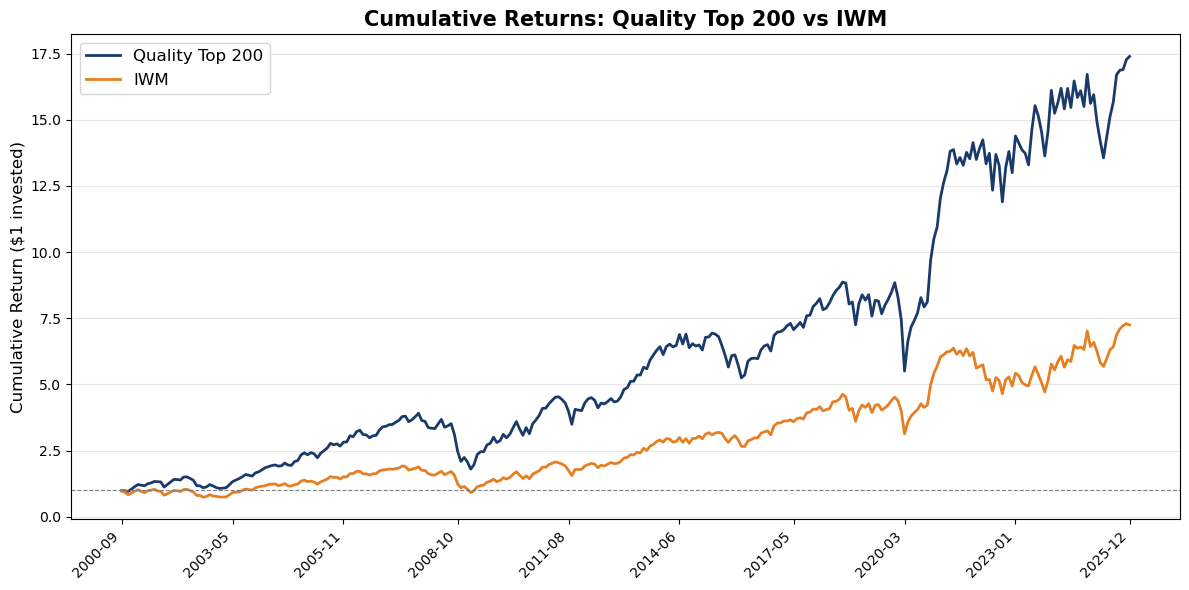

In [13]:
analysis['cum_port'] = (1 + analysis['port_ret']).cumprod()
analysis['cum_iwm']  = (1 + analysis['iwm_ret']).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(range(len(analysis)), analysis['cum_port'].values, color='#1a3a6b', lw=2, label='Quality Top 200')
ax.plot(range(len(analysis)), analysis['cum_iwm'].values,  color='#e67e22', lw=2, label='IWM')
ax.set_title('Cumulative Returns: Quality Top 200 vs IWM', fontsize=15, fontweight='bold')
ax.set_ylabel('Cumulative Return ($1 invested)', fontsize=12)
ax.legend(fontsize=12, loc='upper left')
ax.axhline(1, color='gray', lw=0.8, ls='--')
ticks = np.linspace(0, len(analysis)-1, 10, dtype=int)
ax.set_xticks(ticks)
ax.set_xticklabels(analysis['year_month'].iloc[ticks].values, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Stress periods

Global Financial Crisis, Covid crash and the 2022 rate shock.

In [14]:
stress_periods = {
    'Financial Crisis': ('2008-09', '2009-03'),
    'Covid Crash':      ('2020-02', '2020-04'),
    '2022 Rate Shock':  ('2022-01', '2022-12'),
}

print("STRESS PERIOD ANALYSIS")
print("=" * 68)
print(f"{'Period':<22} {'Qual Ret':>10} {'IWM Ret':>10} {'Qual DD':>10} {'IWM DD':>10}")
print("-" * 68)

for name, (start, end) in stress_periods.items():
    mask = (analysis['year_month'] >= start) & (analysis['year_month'] <= end)
    sub = analysis[mask]
    if len(sub) == 0:
        print(f"{name:<22} {'N/A':>10} {'N/A':>10} {'N/A':>10} {'N/A':>10}")
        continue
    q_cum = (1 + sub['port_ret']).cumprod()
    i_cum = (1 + sub['iwm_ret']).cumprod()
    q_ret = q_cum.iloc[-1] - 1
    i_ret = i_cum.iloc[-1] - 1
    q_dd  = (q_cum / q_cum.cummax() - 1).min()
    i_dd  = (i_cum / i_cum.cummax() - 1).min()
    diff  = q_ret - i_ret
    note  = "Quality protected" if diff > 0 else "Quality underperformed"
    print(f"{name:<22} {q_ret:>9.1%} {i_ret:>10.1%} {q_dd:>10.1%} {i_dd:>10.1%}   {note}")

STRESS PERIOD ANALYSIS
Period                   Qual Ret    IWM Ret    Qual DD     IWM DD
--------------------------------------------------------------------
Financial Crisis          -44.1%     -42.3%     -42.2%     -42.0%   Quality underperformed
Covid Crash               -20.2%     -18.5%     -26.0%     -21.5%   Quality underperformed
2022 Rate Shock            -8.0%     -20.5%     -16.4%     -19.0%   Quality protected


## 12. Risks and limitations

- **Open audit items:** the issues still marked *Open* in `AUDIT.md` affect the results in this notebook. Treat all numbers as provisional until every fix is applied.
- **Transaction costs:** results are gross of trading costs. Quarterly rebalancing of 200 small caps with wide bid-ask spreads would lower net returns.
- **Look-ahead risk:** accounting data is aligned to June of the following year, but exact filing dates are not checked stock by stock.
- **Capacity:** an equal-weighted small-cap portfolio faces liquidity limits at institutional scale.
- **Data mining:** the quality composite was chosen from many possible measures; results need out-of-sample validation.
